# Modelo Final: Regresión Logística con Umbral Ajustado

En este notebook se implementa un modelo de regresión logística como modelo final del estudio. 

El umbral de clasificación se ajusta a 0.56 con el objetivo de maximizar el F1-score, en lugar de utilizar el valor por defecto de 0.5.

Se evalúa el desempeño mediante métricas estándar de clasificación y matriz de confusión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [2]:
df = pd.read_csv(r"C:\Users\Daniel Herrera\Documents\Personal\MCD\Tesis\Datos Tesis\Data_Crimes_2001.csv")

In [6]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y %I:%M:%S %p"
)

In [7]:
df["Hour"] = df["Date"].dt.hour
df["DayOfWeek"] = df["Date"].dt.day_name()

In [8]:
df[["Hour", "DayOfWeek"]].head()

,Hour,DayOfWeek
0,23,Monday
1,23,Monday
2,23,Monday
3,23,Monday
4,23,Monday


## Definición de variables

El objetivo del modelo es predecir la probabilidad de que un incidente resulte en arresto.

Variable dependiente (Y):
- Arrest (1 = hubo arresto, 0 = no hubo arresto)

Variables independientes (X):
- Primary Type (tipo de delito)
- District (distrito policial)
- Location Description (tipo de ubicación)
- Hour (hora del incidente)
- DayOfWeek (día de la semana)

Estas variables fueron seleccionadas por su relevancia estadística previa (Cramer's V) y su interpretabilidad criminológica.

In [10]:
y = df["Arrest"]

X = df[[
    "Primary Type",
    "District",
    "Location Description",
    "Hour",
    "DayOfWeek"
]]

X.head()

,Primary Type,District,Location Description,Hour,DayOfWeek
0,THEFT,12,STREET,23,Monday
1,CRIMINAL DAMAGE,8,STREET,23,Monday
2,CRIMINAL DAMAGE,9,STREET,23,Monday
3,BATTERY,14,STREET,23,Monday
4,BATTERY,10,STREET,23,Monday


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "Primary Type",
    "District",
    "Location Description",
    "DayOfWeek"
]

numeric_features = ["Hour"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
threshold = 0.56

y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_prob >= threshold).astype(int)

In [14]:
results = {
    "Accuracy": accuracy_score(y_test, y_pred_adjusted),
    "Precision": precision_score(y_test, y_pred_adjusted),
    "Recall": recall_score(y_test, y_pred_adjusted),
    "F1": f1_score(y_test, y_pred_adjusted),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame([results])

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.856061,0.838219,0.628546,0.718396,0.868501


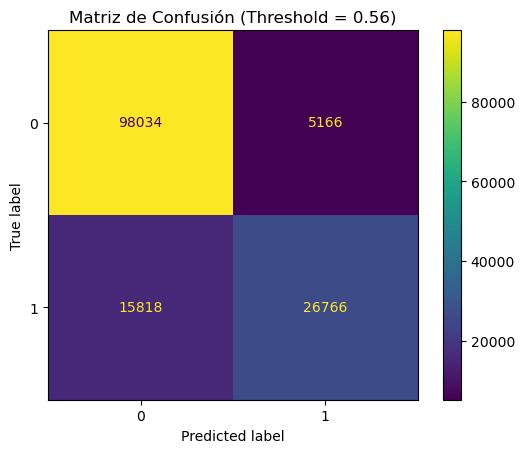

In [15]:
cm = confusion_matrix(y_test, y_pred_adjusted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión (Threshold = 0.56)")
plt.show()

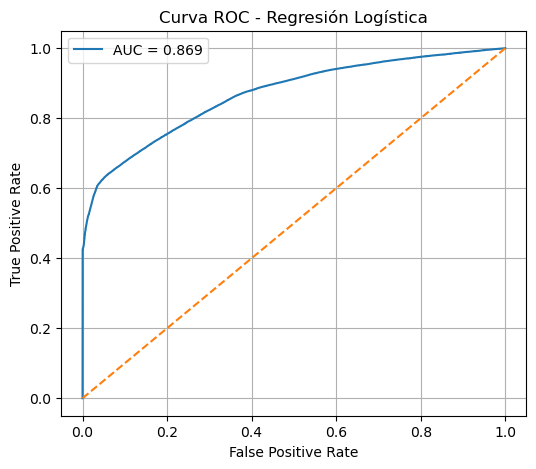

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {results['ROC_AUC']:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid()
plt.show()

## Conclusión
El ajuste del umbral de decisión permitió mejorar significativamente el equilibrio entre precisión y sensibilidad, incrementando el F1-score en aproximadamente 4 puntos porcentuales. Esto sugiere que el valor estándar de 0.5 no era óptimo para este problema específico. El modelo final supera incluso al RandomForest en desempeño global, manteniendo además mayor interpretabilidad y menor costo computacional.